In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!file /content/drive/MyDrive/Miniprojectdataset.zip

/content/drive/MyDrive/Miniprojectdataset.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
!unzip -q "/content/drive/MyDrive/Miniprojectdataset.zip" -d /content/dataset

In [ ]:
!pip install timm scikit-learn matplotlib pandas pillow

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import timm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
ROOT_DIR = "/content/dataset"
IMG_DIR = os.path.join(ROOT_DIR, "resized_train", "resized_train")
CSV_PATH = os.path.join(ROOT_DIR, "trainLabels_cropped.csv")

In [ ]:
df = pd.read_csv(CSV_PATH)
print(df.head())
print("\nClass Distribution:\n", df["level"].value_counts())

   Unnamed: 0.1  Unnamed: 0     image  level
0             0           0   10_left      0
1             1           1  10_right      0
2             2           2   13_left      0
3             3           3  13_right      0
4             4           4   15_left      1

Class Distribution:
 level
0    25802
2     5288
1     2438
3      872
4      708
Name: count, dtype: int64


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["level"],
    random_state=42
)

# Add the .jpeg extension to the image names in both dataframes
train_df['image'] = train_df['image'].apply(lambda x: x + '.jpeg')
test_df['image'] = test_df['image'].apply(lambda x: x + '.jpeg')

# Get a set of existing image filenames in the image directory
existing_files = set(os.listdir(IMG_DIR))

# Filter train_df and test_df to include only images that exist
train_df = train_df[train_df['image'].isin(existing_files)].reset_index(drop=True)
test_df = test_df[test_df['image'].isin(existing_files)].reset_index(drop=True)

print(f"Original train_df size: {len(df) * 0.8}")
print(f"Filtered train_df size: {len(train_df)}")
print(f"Original test_df size: {len(df) * 0.2}")
print(f"Filtered test_df size: {len(test_df)}")

Original train_df size: 28086.4
Filtered train_df size: 28086
Original test_df size: 7021.6
Filtered test_df size: 7022


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [ ]:
class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image"]
        label = int(self.df.loc[idx, "level"])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = DRDataset(train_df, IMG_DIR, transform)
test_dataset  = DRDataset(test_df, IMG_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=5
)
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {loss_sum:.3f} "
          f"Train Accuracy: {correct/total:.4f}")

Epoch [1/10] Loss: 1448.892 Train Accuracy: 0.7382
Epoch [2/10] Loss: 1231.637 Train Accuracy: 0.7711
Epoch [3/10] Loss: 1127.808 Train Accuracy: 0.7909
Epoch [4/10] Loss: 1034.130 Train Accuracy: 0.8097
Epoch [5/10] Loss: 941.905 Train Accuracy: 0.8268
Epoch [6/10] Loss: 855.865 Train Accuracy: 0.8422
Epoch [7/10] Loss: 740.614 Train Accuracy: 0.8636
Epoch [8/10] Loss: 659.857 Train Accuracy: 0.8773
Epoch [9/10] Loss: 572.194 Train Accuracy: 0.8925
Epoch [10/10] Loss: 489.249 Train Accuracy: 0.9056


In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\nTest Accuracy:", acc)
print("\nConfusion Matrix:\n", cm)


Test Accuracy: 0.7634577043577329

Confusion Matrix:
 [[4729  237  192    0    3]
 [ 400   39   49    0    0]
 [ 468   68  472   43    7]
 [  14    3   86   69    2]
 [  27    0   48   14   52]]


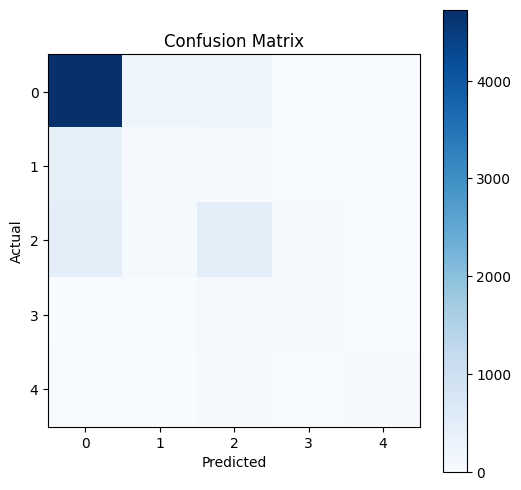

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
stages = ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Proliferative DR"]

for i in range(10):
    img, label = test_dataset[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()

    print(f"Actual: {stages[label]} | Predicted: {stages[pred]}")

Actual: Moderate DR | Predicted: No DR
Actual: No DR | Predicted: No DR
Actual: No DR | Predicted: No DR
Actual: No DR | Predicted: No DR
Actual: No DR | Predicted: No DR
Actual: No DR | Predicted: No DR
Actual: Moderate DR | Predicted: Moderate DR
Actual: No DR | Predicted: Mild DR
Actual: No DR | Predicted: No DR
Actual: No DR | Predicted: No DR


In [ ]:
torch.save(model.state_dict(), "swin_dr_classifier1.pth")

In [ ]:
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.ConvTranspose2d(64, 1, 2, stride=2)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return torch.sigmoid(x)

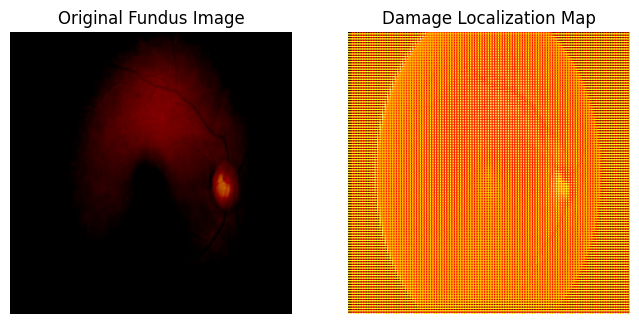

In [ ]:
attn_model = AttentionUNet().to(device)
attn_model.eval()

img, _ = test_dataset[0]

with torch.no_grad():
    mask = attn_model(img.unsqueeze(0).to(device))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Original Fundus Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[0][0].cpu(), cmap="hot")
plt.title("Damage Localization Map")
plt.axis("off")

plt.show()

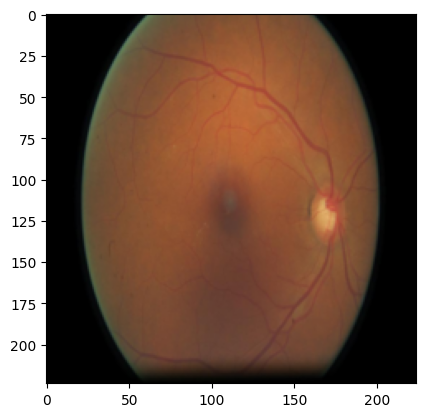

In [ ]:
img_plot = (img * 0.5 + 0.5).permute(1,2,0)
plt.imshow(img_plot)

In [ ]:
print(f"Final Test Accuracy: {acc*100:.2f}%")

Final Test Accuracy: 76.35%


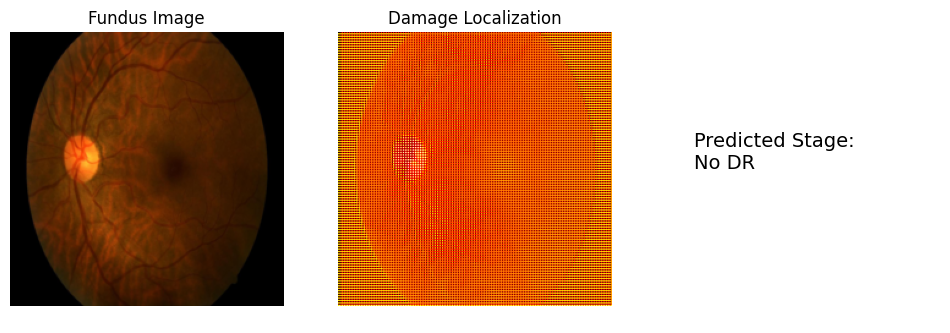

In [ ]:
img, label = test_dataset[3]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
    mask = attn_model(img.unsqueeze(0).to(device))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow((img*0.5+0.5).permute(1,2,0))
plt.title("Fundus Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask[0][0].cpu(), cmap="hot")
plt.title("Damage Localization")
plt.axis("off")

plt.subplot(1,3,3)
plt.text(0.1, 0.5, f"Predicted Stage:\n{stages[pred]}", fontsize=14)
plt.axis("off")

plt.show()

In [ ]:
torch.save(model.state_dict(), "final_swin_dr_model1.pth")
torch.save(attn_model.state_dict(), "attention_unet1.pth")

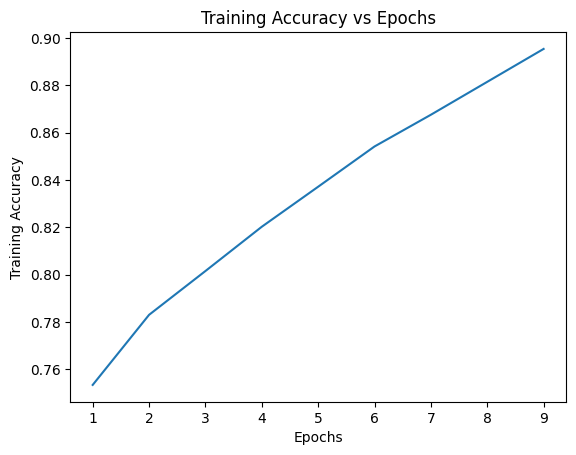

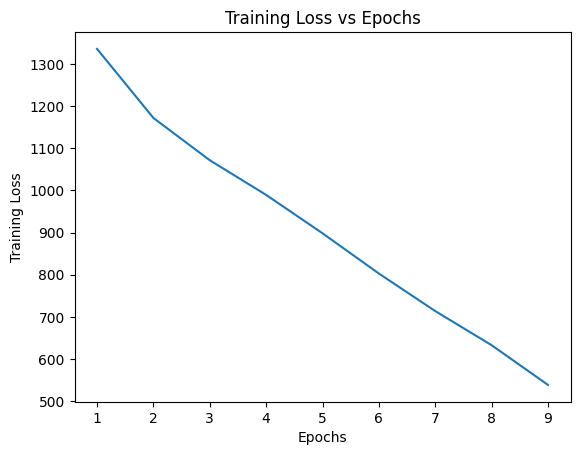

In [ ]:
import matplotlib.pyplot as plt

# Store values during training
train_accuracy = [0.7534, 0.7830, 0.8015, 0.8202, 0.8371, 0.8541, 0.8675, 0.8814, 0.8953]
train_loss = [1335.403, 1171.634, 1071.383, 989.181, 898.219, 802.727, 713.705, 632.799, 538.613]
epochs = range(1, len(train_accuracy) + 1)

# Accuracy Plot
plt.figure()
plt.plot(epochs, train_accuracy)
plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.show()

# Loss Plot
plt.figure()
plt.plot(epochs, train_loss)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()

In [ ]:
torch.save(model.state_dict(), "final_model1.pth")